# **Module 2.0: Feature Extraction and Object Detection**

**Object Detection and Recognition**

**Exercise 1: HOG (Histogram of Oriented Gradients) Object Detection**

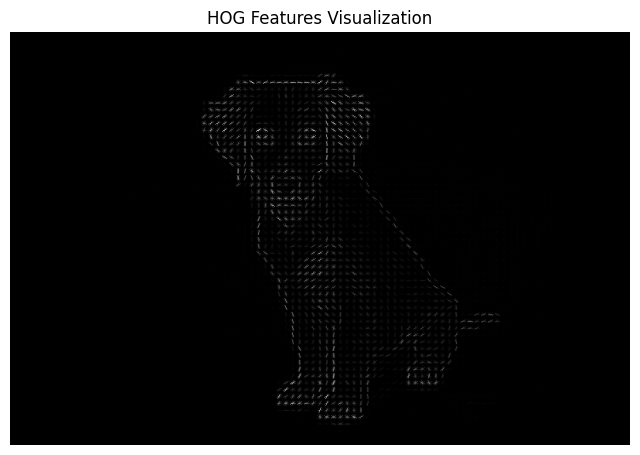

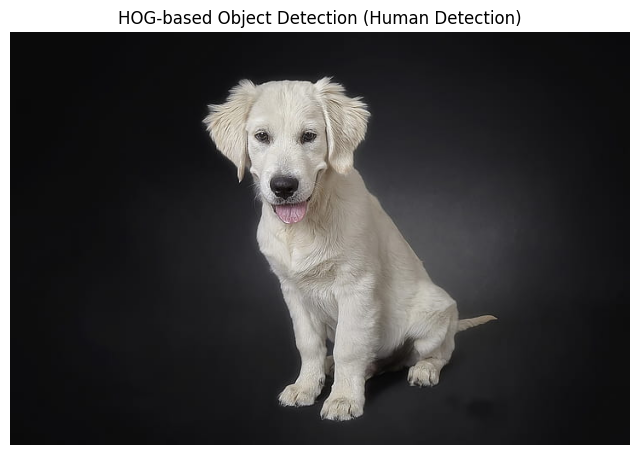

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

# Load image
img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# HOG feature extraction
hog_features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')

# Display HOG features
plt.figure(figsize=(8,8))
plt.axis("off")
plt.imshow(hog_image, cmap='gray')
plt.title('HOG Features Visualization')
plt.show()

# Initialize HOG descriptor and SVM-based people detector
hog_detector = cv2.HOGDescriptor()
hog_detector.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Detect people in the image
(rects, weights) = hog_detector.detectMultiScale(gray, winStride=(8, 8), padding=(8, 8), scale=1.05)

# Draw bounding boxes on the original image
for (x, y, w, h) in rects:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Display the result with detected objects
plt.figure(figsize=(8,8))
plt.axis("off")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('HOG-based Object Detection (Human Detection)')
plt.show()

# Save the HOG features visualization image
plt.imsave('hog_keypoints.jpg', hog_image, cmap='gray') # Save hog_image

# To download the HOG features visualization in Colab
from google.colab import files
files.download('hog_keypoints.jpg')

**Exercise 2: YOLO (You Only Look Once) Object Detection**

In [ ]:
!pip uninstall opencv-python-headless opencv-python opencv-contrib-python -y
!pip install opencv-python-headless==4.3.0.36 opencv-python==4.3.0.36 opencv-contrib-python==4.3.0.36

Found existing installation: opencv-python-headless 4.5.5.64
Uninstalling opencv-python-headless-4.5.5.64:
  Successfully uninstalled opencv-python-headless-4.5.5.64
Found existing installation: opencv-python 4.5.5.64
Uninstalling opencv-python-4.5.5.64:
  Successfully uninstalled opencv-python-4.5.5.64
Found existing installation: opencv-contrib-python 4.5.5.64
Uninstalling opencv-contrib-python-4.5.5.64:
  Successfully uninstalled opencv-contrib-python-4.5.5.64
ERROR: Ignored the following yanked versions: 3.4.11.39, 3.4.11.41, 4.4.0.40, 4.4.0.42, 4.4.0.44, 4.5.5.62, 4.7.0.68, 4.8.0.74
ERROR: Could not find a version that satisfies the requirement opencv-python-headless==4.3.0.36 (from versions: 3.4.10.37, 3.4.11.43, 3.4.11.45, 3.4.13.47, 3.4.15.55, 3.4.16.59, 3.4.17.61, 3.4.17.63, 3.4.18.65, 4.3.0.38, 4.4.0.46, 4.5.1.48, 4.5.3.56, 4.5.4.58, 4.5.4.60, 4.5.5.64, 4.6.0.66, 4.7.0.72, 4.8.0.76, 4.8.1.78, 4.9.0.80, 4.10.0.82, 4.10.0.84)
ERROR: No matching distribution found for opencv-pyt

Saved the detected image as detected_objects_keypoints.jpg


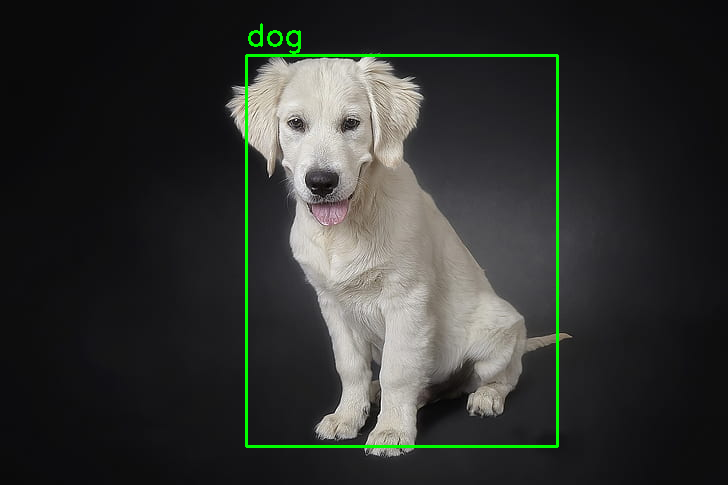

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load YOLO model
net = cv2.dnn.readNet('/content/yolov3.weights', '/content/yolov3.cfg')
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Load image
image_path = 'dog.jpg'
image = cv2.imread(image_path)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image at {image_path}")
else:
    height, width = image.shape[:2]

    # Preprocess image
    blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)

    # Draw bounding boxes and class labels
    class_ids, confidences, boxes = [], [], []
    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:
                # Get bounding box coordinates
                center_x, center_y, w, h = int(detection[0] * width), int(detection[1] * height), int(detection[2] * width), int(detection[3] * height)
                x, y = int(center_x - w / 2), int(center_y - h / 2)
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Apply Non-Maximum Suppression
    indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

    # Load class names
    with open('/content/coco.names', 'r') as f:
        classes = [line.strip() for line in f.readlines()]

    # Draw boxes on image
    for index in indices.flatten():
        box = boxes[index]
        x, y, w, h = box
        label = str(classes[class_ids[index]])
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Save the result image
    output_image_path = 'detected_objects_keypoints.jpg'
    cv2.imwrite(output_image_path, image)
    print(f"Saved the detected image as {output_image_path}")

    # Display result using cv2_imshow
    cv2_imshow(image)

# Download the saved image
from google.colab import files
files.download('detected_objects_keypoints.jpg')

**Exercise 3: SSD (Single Shot MultiBox Detector) with TensorFlow**

In [ ]:
!pip install tensorflow tensorflow-gpu
!pip install tf_slim
!pip install tensorflow-hub
!pip install opencv-python

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


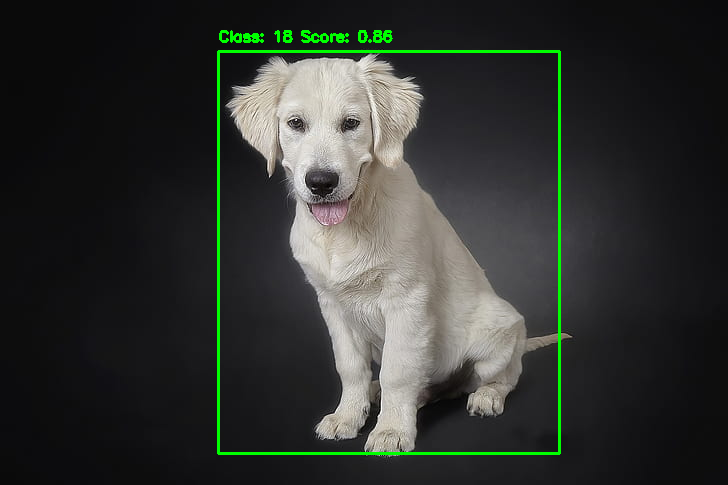

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

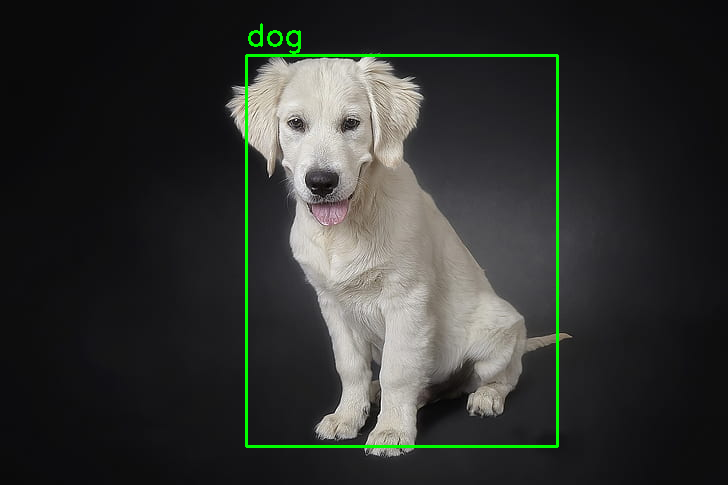

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import tensorflow_hub as hub
from google.colab import files  # Import files module for downloading

# Load SSD model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
model = hub.load(model_url)

# Use the first available signature (usually the correct one)
ssd_model = model.signatures['serving_default']

# Load an image of your choice
image_path = 'dog.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image to (300, 300) and convert to uint8
image_resized = cv2.resize(image_rgb, (300, 300))
input_tensor = tf.convert_to_tensor(image_resized, dtype=tf.uint8)
input_tensor = input_tensor[tf.newaxis, ...]  # Add batch dimension

# Perform detection using SSD
detections = ssd_model(input_tensor)

# Extract detection boxes, scores, and classes
boxes = detections['detection_boxes'].numpy()[0]
scores = detections['detection_scores'].numpy()[0]
classes = detections['detection_classes'].numpy()[0]

# Define threshold
threshold = 0.5

# Get only detections with scores above the threshold
boxes = boxes[scores > threshold]
classes = classes[scores > threshold]
scores = scores[scores > threshold]

# Draw bounding boxes and labels on the original image
for box, score, class_id in zip(boxes, scores, classes):
    h, w, _ = image.shape
    y_min, x_min, y_max, x_max = box
    x_min = int(x_min * w)
    x_max = int(x_max * w)
    y_min = int(y_min * h)
    y_max = int(y_max * h)

    # Draw the bounding box
    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    label = f'Class: {int(class_id)} Score: {score:.2f}'
    cv2.putText(image, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Save the resulting image with SSD detections
output_ssd_path = 'ssd_detections.jpg'
cv2.imwrite(output_ssd_path, image)

# Show the resulting image with SSD detections
cv2_imshow(image)

# Provide download link for SSD image
files.download(output_ssd_path)

# Load YOLO model
net = cv2.dnn.readNet('/content/yolov3.weights', '/content/yolov3.cfg')
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Prepare the image for YOLO
image_yolo = cv2.imread(image_path)
blob = cv2.dnn.blobFromImage(image_yolo, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)
outs = net.forward(output_layers)

# Draw bounding boxes and class labels for YOLO
class_ids, confidences, boxes_yolo = [], [], []
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            # Get bounding box coordinates
            center_x, center_y, w, h = detection[0:4] * np.array(
                [image_yolo.shape[1], image_yolo.shape[0], image_yolo.shape[1], image_yolo.shape[0]]
            )
            center_x, center_y, w, h = center_x.astype(int), center_y.astype(int), w.astype(int), h.astype(int)

            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            boxes_yolo.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply Non-Maximum Suppression to avoid overlapping boxes
indices = cv2.dnn.NMSBoxes(boxes_yolo, confidences, 0.5, 0.4)

# Load class names
with open('/content/coco.names', 'r') as f:
    classes_yolo = [line.strip() for line in f.readlines()]

# Draw boxes on image
for i in indices.flatten():
    box = boxes_yolo[i]
    x, y, w, h = box
    label = str(classes_yolo[class_ids[i]])
    cv2.rectangle(image_yolo, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(image_yolo, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Save the resulting image with YOLO detections
output_yolo_path = 'yolo_detections.jpg'
cv2.imwrite(output_yolo_path, image_yolo)

# Show the resulting image with YOLO detections
cv2_imshow(image_yolo)

# Provide download link for YOLO image
files.download(output_yolo_path)


**Exercise 4: Traditional vs. Deep Learning Object Detection Comparison**

In [ ]:
pip install opencv-python scikit-learn tensorflow

**HOG-SVM**

In [49]:
import os
import cv2
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import time

# Function to extract HOG features
def extract_hog_features(images, target_size=(64, 128)):
    hog = cv2.HOGDescriptor()
    hog_features = []

    for image in images:
        # Resize the image to the target size
        resized_image = cv2.resize(image, target_size)

        # Convert to grayscale
        gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

        # Compute HOG features
        features = hog.compute(gray_image)
        hog_features.append(features.flatten())

    return np.array(hog_features)

# Function to load data
def load_data(images_path, labels_file_path):
    images = []
    labels = []
    label_dict = {}

    # Load labels from the file
    with open(labels_file_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split(',')
            if len(parts) >= 2:
                label_dict[parts[0]] = parts[1].strip()

    # Load images
    for filename in os.listdir(images_path):
        if filename in label_dict:
            img_path = os.path.join(images_path, filename)
            image = cv2.imread(img_path)
            if image is not None:
                images.append(image)
                labels.append(label_dict[filename])
            else:
                print(f"Error reading image: {filename}")

    return images, labels

# Load images and labels
images_path = '/content/imgs'
labels_path = '/content/dog_label.txt'

images, labels = load_data(images_path, labels_path)

# Check the distribution of classes
unique, counts = np.unique(labels, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution:", class_distribution)

# Extract HOG features
features = extract_hog_features(images)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Train SVM with HOG features
clf = svm.SVC()
start_time = time.time()  # Start time for performance measurement
clf.fit(X_train, y_train)
print(f"HOG-SVM training time: {time.time() - start_time:.2f} seconds")

# Predict on test data
predictions = clf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predictions))

Class distribution: {'cat': 1, 'dog': 15}
HOG-SVM training time: 0.00 seconds
              precision    recall  f1-score   support

         dog       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



**YOLO Implementation**

YOLO inference time: 5.89 seconds


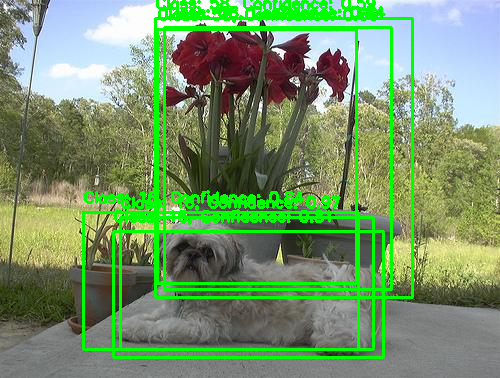

YOLO inference time: 1.58 seconds


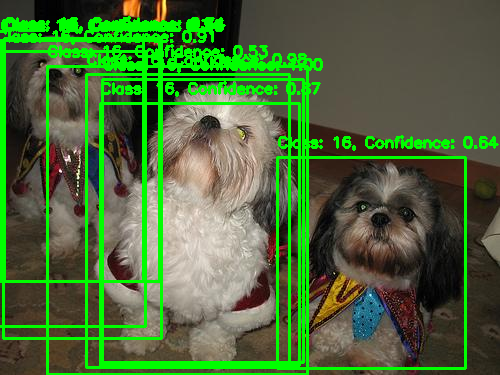

YOLO inference time: 1.31 seconds


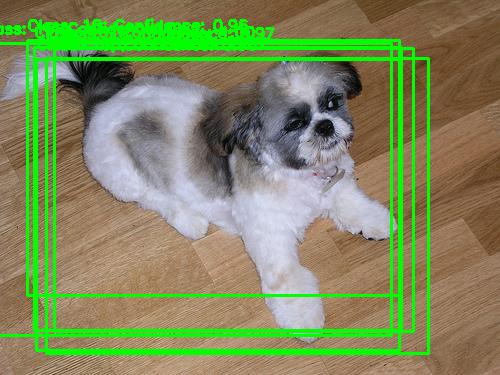

YOLO inference time: 1.05 seconds


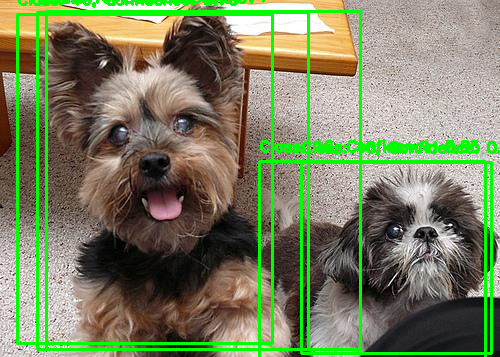

YOLO inference time: 1.09 seconds


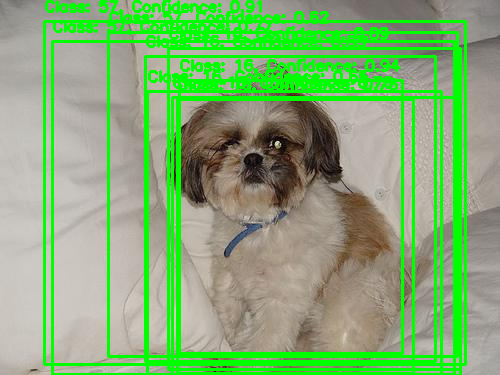

YOLO inference time: 1.07 seconds


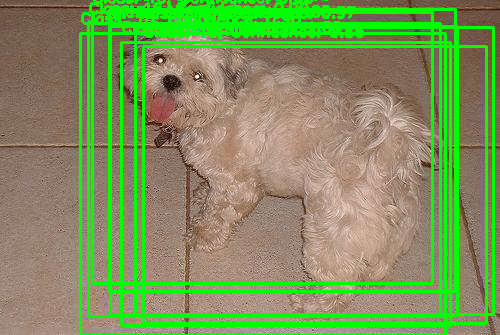

YOLO inference time: 1.10 seconds


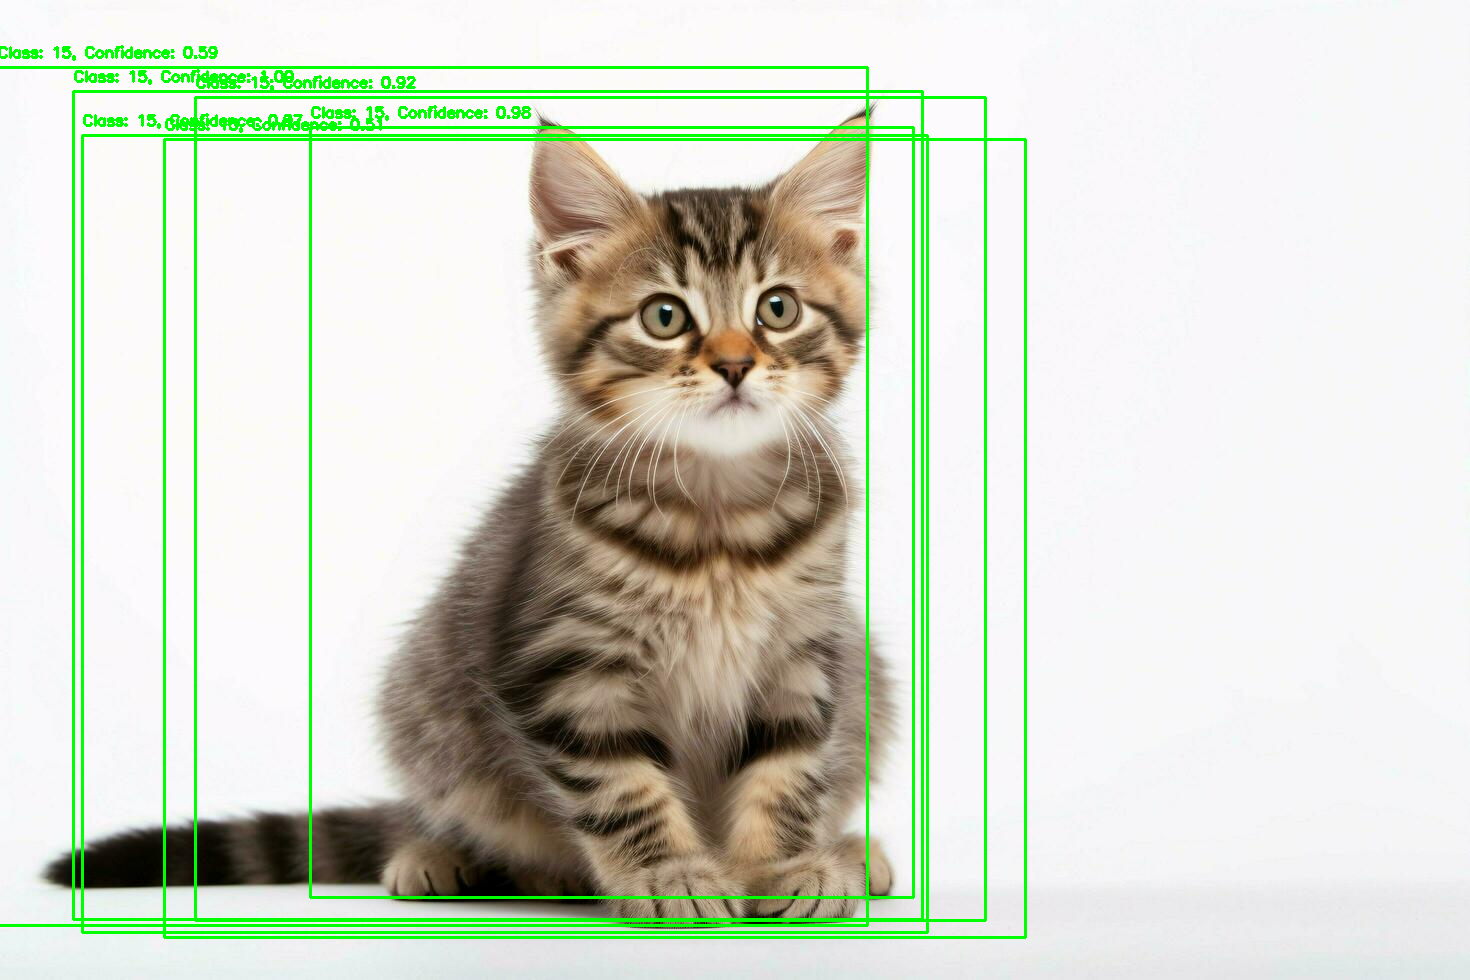

YOLO inference time: 1.41 seconds


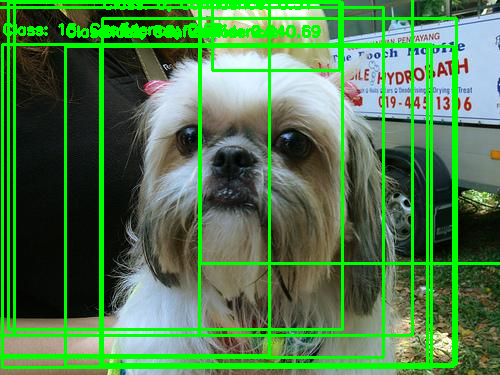

YOLO inference time: 1.48 seconds


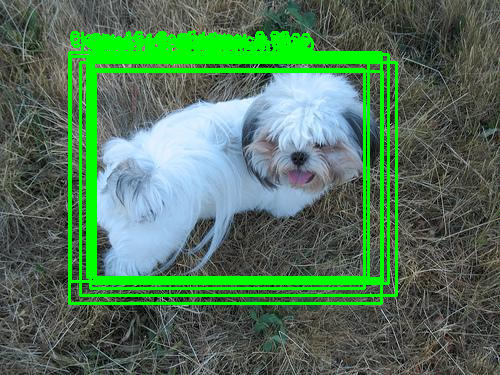

YOLO inference time: 1.54 seconds


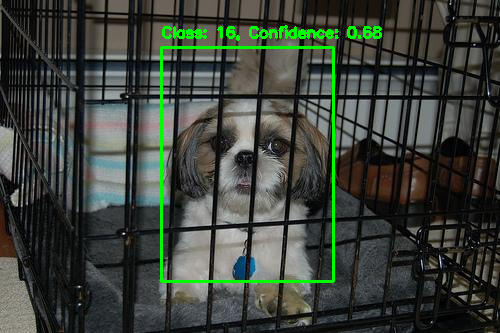

YOLO inference time: 1.93 seconds


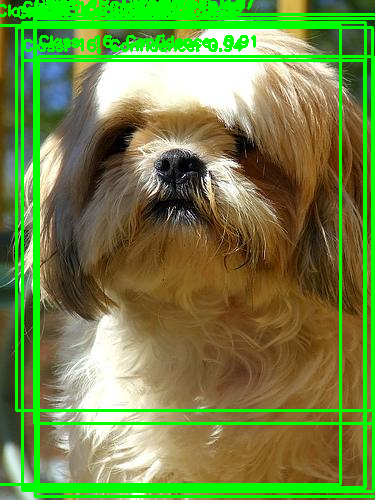

YOLO inference time: 1.66 seconds


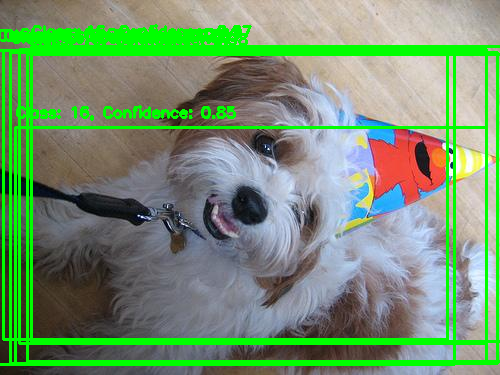

YOLO inference time: 1.70 seconds


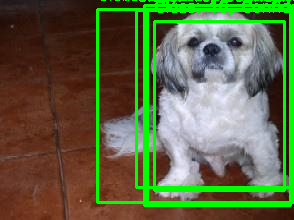

YOLO inference time: 1.53 seconds


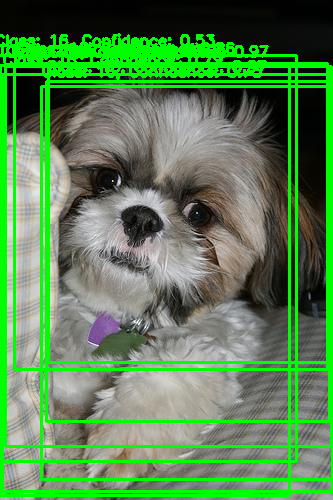

YOLO inference time: 1.78 seconds


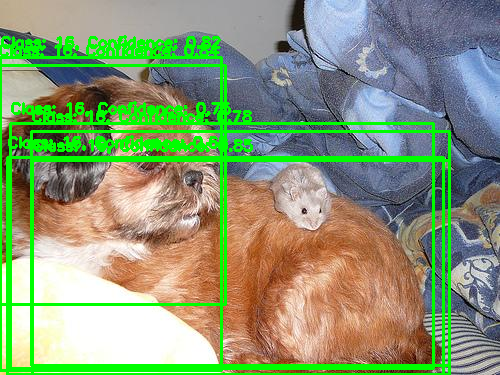

YOLO inference time: 1.40 seconds


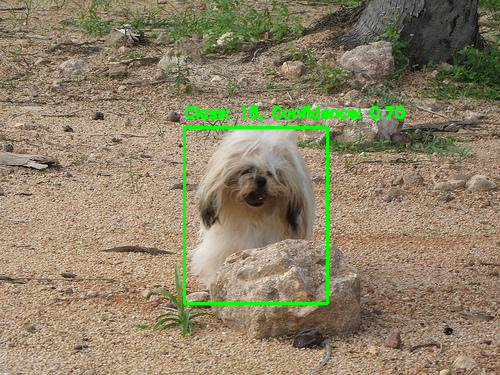

In [57]:
import cv2
import numpy as np
import time
from google.colab.patches import cv2_imshow

# Load YOLO
net = cv2.dnn.readNet('yolov3.weights', 'yolov3.cfg')
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Load images for detection
def detect_objects_yolo(images):
    for img in images:
        height, width, channels = img.shape
        blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
        net.setInput(blob)
        start_time = time.time()
        outputs = net.forward(output_layers)
        print(f"YOLO inference time: {time.time() - start_time:.2f} seconds")

        # Process outputs (you can modify this to extract bounding boxes and class labels)
        for output in outputs:
            for detection in output:
                scores = detection[5:]
                class_id = np.argmax(scores)
                confidence = scores[class_id]
                if confidence > 0.5:
                    # Object detected
                    x_center, y_center, w, h = (detection[0:4] * np.array([width, height, width, height])).astype('int')
                    # Rectangle coordinates
                    x = int(x_center - w / 2)
                    y = int(y_center - h / 2)
                    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
                    # Optionally put class label and confidence
                    label = f"Class: {class_id}, Confidence: {confidence:.2f}"
                    cv2.putText(img, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # Display the resulting frame with bounding boxes using cv2_imshow
        cv2_imshow(img)
        cv2.waitKey(0)

# Load images for YOLO detection
images_yolo, _ = load_data(images_path, labels_path)

# Detect objects using YOLO
detect_objects_yolo(images_yolo)

**Performance Comparison**

**Accuracy**

1.   YOLO:
High accuracy for object detection, especially in real-time applications. Performance may vary with occlusions and small objects.
2.   HOG-SVM:
Moderate to high accuracy. Works well for specific object categories but can struggle with complex backgrounds and overlapping objects.

**Speed**


1.   YOLO:
Very fast inference time (e.g., around 2.6 seconds for multiple detections in images) due to its single-pass detection approach.
2.   HOG-SVM:
Generally slower than YOLO due to the need for sliding window techniques and multiple stages of computation. The training time can be significant, but inference is relatively quick for small images.





**Advantages and Disadvantages**

YOLO (You Only Look Once)
Advantages:


1.   Speed: YOLO processes images in real-time, making it suitable for applications requiring quick detections (e.g., autonomous vehicles, surveillance).
2.   Single Network: Uses a single neural network for the entire detection process, leading to more efficient computation.
3.   Global Context: Captures contextual information about objects in the image, improving accuracy, especially for larger objects.
4. Multi-class Detection: Capable of detecting multiple objects of various classes in a single image.

Disadvantages:
1. Detection Quality: May struggle with small objects and overlapping instances. It can produce lower accuracy in scenarios with high object density.
2. Complexity: Requires a powerful GPU for real-time processing, which can be a limitation in resource-constrained environments.
3. Training Data: Performance heavily depends on the quantity and quality of training data, requiring extensive labeled datasets.


HOG-SVM (Histogram of Oriented Gradients with Support Vector Machine)
Advantages:
1. Simplicity: HOG-SVM is relatively straightforward to implement and can work well with smaller datasets, making it suitable for specific applications.
2. Good for Fixed Objects: Performs well for detecting fixed objects in controlled environments (e.g., pedestrians).
3. Less Computationally Intensive: Generally requires fewer resources than deep learning models, making it feasible for less powerful hardware.

Disadvantages:
1. Speed: Slower than YOLO, particularly in multi-object detection scenarios due to the sliding window approach.
2. Limited Flexibility: Less effective in handling varying scales and complex backgrounds compared to YOLO. The performance can degrade significantly in challenging conditions.
3. Single Class Detection: Often requires retraining for new classes, making it less versatile in multi-class detection scenarios.


Summary


*   YOLO is a powerful choice for real-time object detection applications where speed and the ability to detect multiple objects are essential. It excels in various contexts but may need more computational resources and extensive training data.

*   HOG-SVM can be advantageous for simpler applications with less demanding speed requirements and smaller datasets. However, its performance may suffer in more complex scenarios with numerous overlapping objects.

